In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
import imageio.v2 as imageio
import os
from PIL import Image
from tqdm import tqdm
import random
import h5py


In [325]:
dir = './data/anatomicalSegmentations/anatomicalSegmentations/'

images = []
print(len(images))
files = sorted([f for f in os.listdir(dir) if f.endswith('.png')])

for file in files:
    img_path = os.path.join(dir, file)
    img = Image.open(img_path).convert('L')  # Convert to grayscale, use 'RGB' if needed
    img_array = np.array(img)
    images.append(img_array)

print(len(images))

# def generate_pointset()

0
150


In [326]:
# plt.imshow(images[0], cmap = 'gray')
# np.unique(images[0])
images[0][128, 180]

168

In [327]:
def generate_pointset(image, num_angles=30):

    cy, cx = (image.shape[0] // 2, image.shape[1] // 2)
    h, w = image.shape
    
    # Generate angles in radians
    angles = np.linspace(0, np.pi, num_angles, endpoint=False)
    
    boundary = []
    
    for theta in angles:
        # Calculate unit vector direction
        dx = np.cos(theta)
        dy = np.sin(theta)
        
        # Initialize points to track along the ray
        x, y = cx, cy
        
        # Variables to store inner and outer boundary points
        found_inner1 = False
        found_inner2 = False
        inner1 = None
        outer1 = None
        inner2 = None
        outer2 = None
        
        # Maximum distance to check (diagonal of the image)
        max_dist = np.sqrt(h**2 + w**2)
        
        for dist in np.arange(0, max_dist, 1):
            x1 = int(cx + dist * dx)
            y1 = int(cy + dist * dy)
            
            if not (0 <= y1 < h and 0 <= x1 < w):
                break
                
            if not found_inner1 and image[y1, x1] > 0:
                inner1 = [y1, x1]
                found_inner1 = True
            elif found_inner1 and image[y1, x1] == 0:
                outer1 = (int(y1 - dy), int(x1 - dx))
                break
        
        # Second direction (negative)
        for dist in np.arange(0, max_dist, 1):
            x2 = int(cx - dist * dx)
            y2 = int(cy - dist * dy)
            
            if not (0 <= y2 < h and 0 <= x2 < w):
                break
                
            if not found_inner2 and image[y2, x2] > 0:
                inner2 = [y2, x2]
                found_inner2 = True
            elif found_inner2 and image[y2, x2] == 0:
                outer2 = (int(y2 + dy), int(x2 + dx))  # Note the sign change here
                break
        
        # Append the points if found
        boundary.append(inner1)
        boundary.append(inner2)
        boundary.append(outer1)
        boundary.append(outer2)
    
    return np.array(boundary)

In [328]:
data = []

# generate inner and outer pointset for all 150 images
for img in images:
    boundary = generate_pointset(img, 30)
    data.append(boundary)

data = np.array(data)

In [329]:
data[0]

array([[128, 168],
       [128,  93],
       [128, 181],
       [128,  72],
       [132, 168],
       [124,  93],
       [132, 181],
       [122,  71],
       [136, 168],
       [120,  93],
       [139, 183],
       [115,  71],
       [140, 166],
       [116,  93],
       [144, 181],
       [109,  71],
       [145, 166],
       [112,  93],
       [150, 179],
       [104,  75],
       [149, 164],
       [110,  96],
       [156, 177],
       [ 98,  76],
       [153, 162],
       [105,  96],
       [160, 173],
       [ 92,  79],
       [156, 159],
       [101,  98],
       [165, 169],
       [ 86,  81],
       [159, 156],
       [ 98, 101],
       [170, 165],
       [ 82,  87],
       [163, 153],
       [ 94, 103],
       [174, 161],
       [ 77,  91],
       [167, 151],
       [ 90, 106],
       [177, 156],
       [ 73,  96],
       [169, 146],
       [ 88, 110],
       [180, 150],
       [ 70, 102],
       [171, 142],
       [ 86, 114],
       [182, 144],
       [ 68, 108],
       [173,

In [330]:
def scatter_plot(pointsets_list, title="Multiple Point Sets", 
                                   use_random_colors=True, marker='o', size=5, alpha=1):

    plt.figure(figsize=(12, 12))
    
    # Process each pointset
    for i, pointset in enumerate(pointsets_list):
            
        # Separate x and y coordinates
        x_coords = [point[0] for point in pointset]
        y_coords = [point[1] for point in pointset]
        
        # Generate a random color for this pointset if requested
        if use_random_colors:
            color = (random.random(), random.random(), random.random())
        else:
            color = None  # Use matplotlib's default color cycle
        
        # Plot this pointset
        plt.scatter(x_coords, y_coords, c=[color], s=size, alpha=alpha, 
                   marker=marker, label=f"Point Set {i+1}")
    
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Add a legend if there aren't too many pointsets
    if len(pointsets_list) <= 10:
        plt.legend()
        
    plt.tight_layout()
    plt.show()

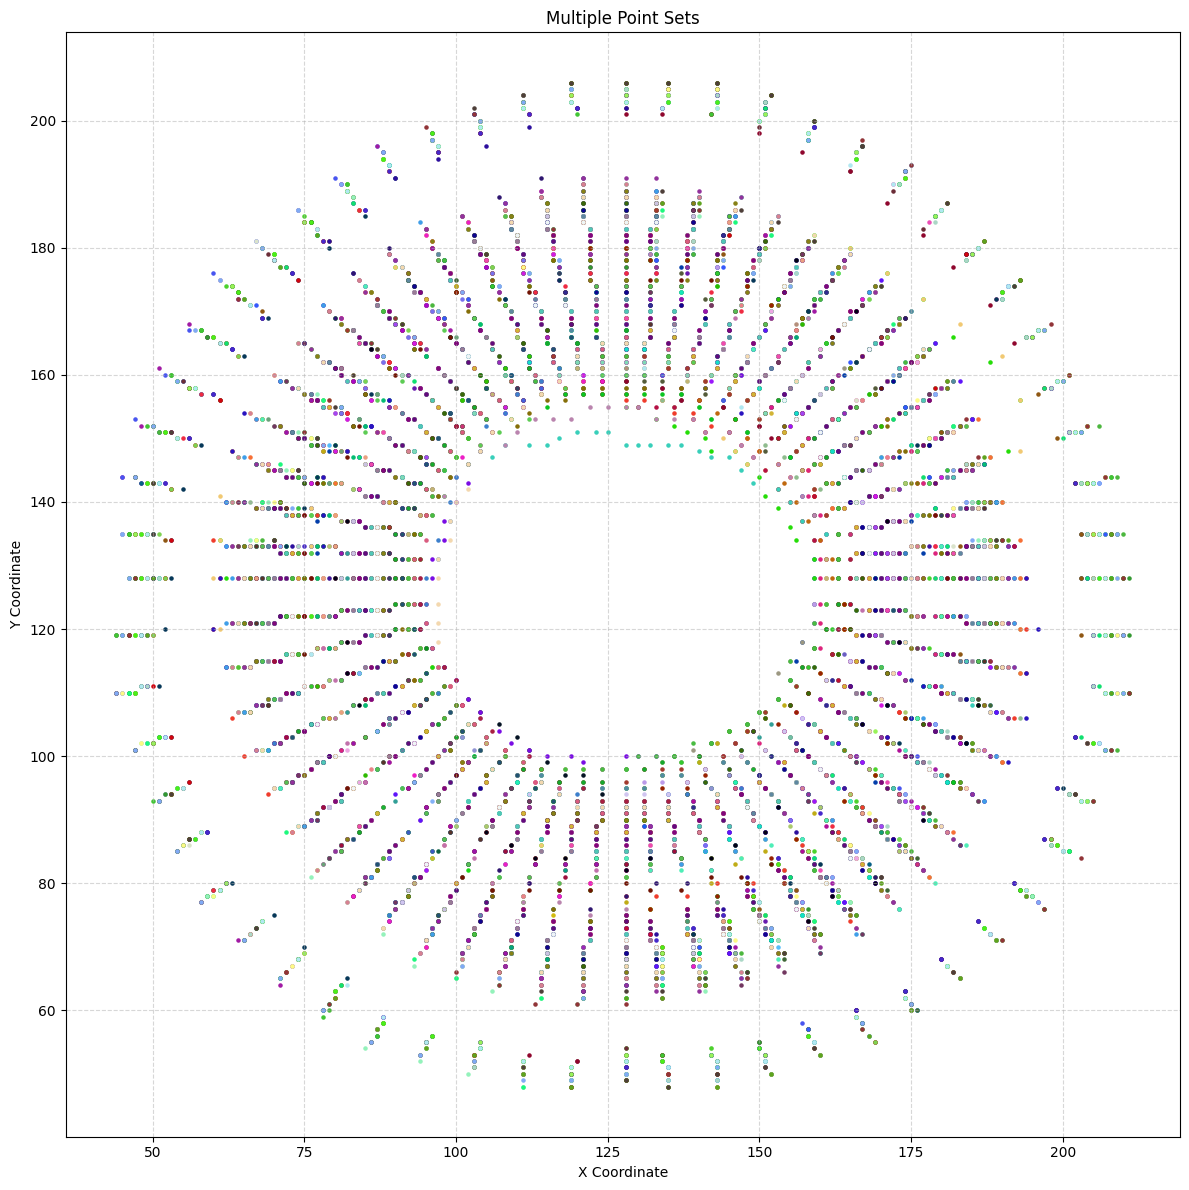

In [331]:
scatter_plot(data)

In [332]:
data = data.astype(float)

In [333]:
# assumes shape1 and shape2 are in pre shape space (centroid 0 and norm 1)
def code1(shape1, shape2):

    cross_covariance = np.dot(shape2.T, shape1)

    
    # singular value decomposition
    U, _, Vt = np.linalg.svd(cross_covariance)
    
    # get determinant to check if valid rotation matrix
    det = np.linalg.det(U) * np.linalg.det(Vt)
    
    # if det < 0, reflection occurs, need to adjust to get only rotation
    if det < 0:
        U_adjusted = U.copy()
        # negate the last column
        U_adjusted[:, -1] = -U[:, -1]
        
        # calculate the adjusted rotation matrix
        R = np.dot(Vt.T, U_adjusted.T)
    else:
        # otherwise, no need of adjustment
        R = np.dot(Vt.T, U.T)
    
    # rotate shape 2 to align with shape 1
    aligned_shape2 = np.dot(shape2, R.T)
    
    # return the norm 
    distance = np.linalg.norm(shape1 - aligned_shape2)
    
    return distance, R


In [334]:
# doesn't assume shape 1 and shape 2 are in pre shape space
# shifts, scales and rotates shape 2 to best fit shape 1
def code2(shape1, shape2):

    n = shape1.shape[0]
    
    x1 = shape1[:, 0]  
    y1 = shape1[:, 1]  
    x2 = shape2[:, 0]  
    y2 = shape2[:, 1]  
    
    # solve: Ac = b where c = [tx, ty, a, b]^T
    
    A = np.zeros((4, 4))
    A[0, 0] = n
    A[0, 2] = -np.sum(x2)
    A[0, 3] = np.sum(y2)
    
    A[1, 1] = n
    A[1, 2] = -np.sum(y2)
    A[1, 3] = -np.sum(x2)
    
    A[2, 0] = np.sum(x2)
    A[2, 1] = np.sum(y2)
    A[2, 2] = -np.sum(x2*x2 + y2*y2)
    
    A[3, 0] = -np.sum(y2)
    A[3, 1] = np.sum(x2)
    A[3, 3] = -np.sum(x2*x2 + y2*y2)
    
    b = np.zeros(4)
    b[0] = np.sum(x1)
    b[1] = np.sum(y1)
    b[2] = np.sum(x1*x2 + y1*y2)
    b[3] = np.sum(y1*x2 - x1*y2)
    
    # solve the linear system
    c = np.linalg.solve(A, b)
    
    # get parameters from solution
    tx, ty, a, b = c

    a = -a
    b = -b
    
    # get scale and rotation from the solution
    s = np.sqrt(a*a + b*b)
    theta = np.arctan2(b, a)
    
    # construct the rotation matrix from theta
    R = np.array([[np.cos(theta), -np.sin(theta)], 
                  [np.sin(theta), np.cos(theta)]])
    
    # translation vector
    T = np.array([tx, ty])
    
    # transform shape 2 using the solution
    M = np.array([[a, -b], [b, a]]) 
    shape2_transformed = np.dot(shape2, M.T) + T
    
    # get the distance
    distance = np.linalg.norm(shape1 - shape2_transformed)
    
    return distance, T, s, R

In [335]:
def code11(pointsets, max_iterations=10000, tolerance=1e-4):

    # pre-processing

    for i in range(len(pointsets)):
        centroid = np.mean(pointsets[i], axis=0, keepdims = True)
        # ensure centroid is origin
        pointsets[i] = pointsets[i] - centroid
        
        # ensure norm is 1
        norm = np.sqrt(np.sum(pointsets[i]**2))
        pointsets[i] = pointsets[i] / norm

    # initialize the mean shape as the 0th shape
    mean_shape = pointsets[0].copy()
    
    for iteration in tqdm(range(max_iterations)):

        aligned_pointsets = []
        for pointset in pointsets:
            # get optimal rotation from code1
            _, R = code1(mean_shape, pointset)
            
            # apply rotation to the pointset to align it
            aligned_pointset = np.dot(pointset, R.T)
            aligned_pointsets.append(aligned_pointset)
        
        # compute the mean shape 
        new_mean = np.mean(aligned_pointsets, axis=0)
        
        # normalize the mean to have norm 1, no need to take care of centroid 0 (ensured by all elements having centroid 0)
        norm = np.sqrt(np.sum(new_mean**2))
        new_mean /= norm
        
        # early termination check
        if np.linalg.norm(new_mean - mean_shape) < tolerance:
            break
        
        # update the mean shape
        mean_shape = new_mean
    
    return mean_shape, aligned_pointsets

  0%|          | 1/10000 [00:00<01:19, 125.26it/s]


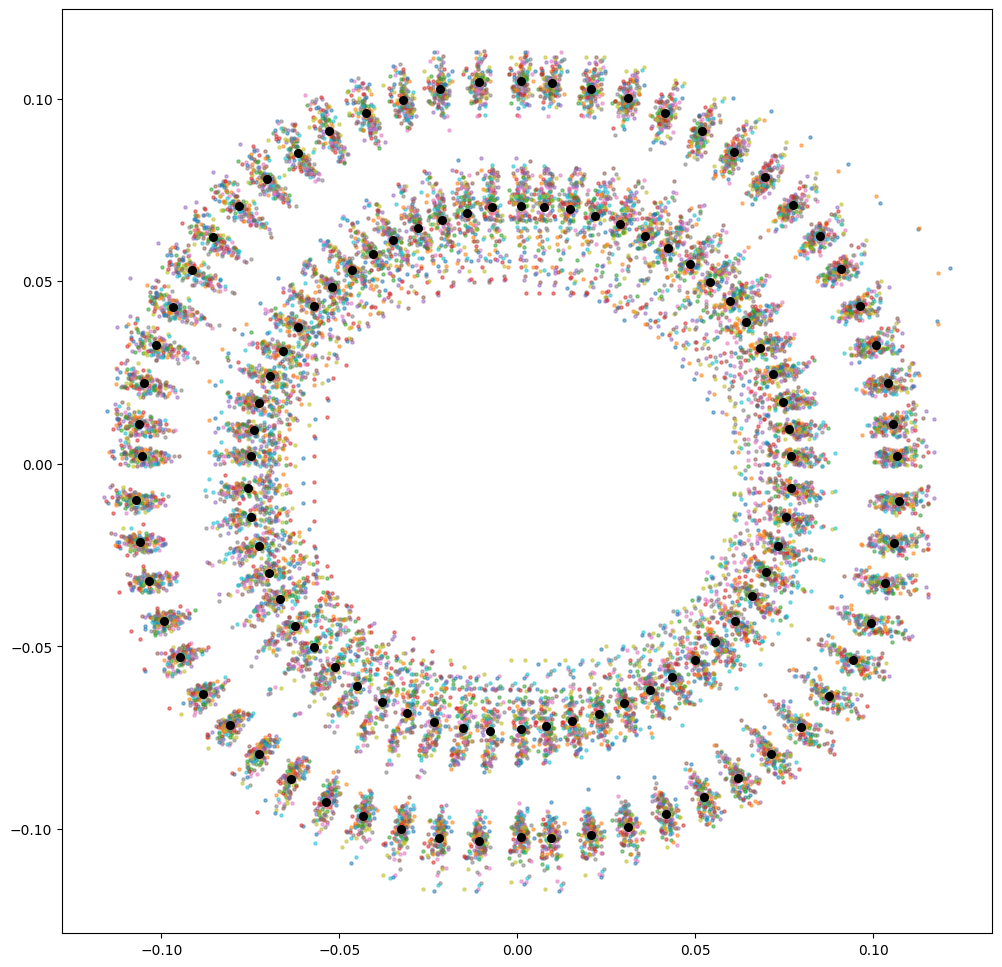

In [336]:
# mean shape - code 11
pointsets11 = data.copy()
mean11, aligned_pointsets_11 = code11(pointsets11)
plt.figure(figsize=(12, 12))
for i, pointset in enumerate(aligned_pointsets_11):
    plt.scatter(pointset[:, 0], pointset[:, 1], label=f'{i}', s = 5, alpha=0.5)

plt.scatter(mean11[:, 0], mean11[:, 1], label=f'Mean Shape', s = 30, c = 'black', alpha = 1.0)


In [337]:
def code22(pointsets, max_iterations=10000, tolerance=1e-4):
    
    # initialize mean shape to the first pointset
    mean_shape = pointsets[0].copy()
    
    # center the initial mean
    centroid = np.mean(mean_shape, axis=0)
    mean_shape -= centroid
    
    for iteration in tqdm(range(max_iterations)):

        # align shapes to current mean
        aligned_pointsets = []
        for pointset in pointsets:
            
            # get optimal scale, translation and rotation to apply to pointset to align best with mean shape
            _, T, s, R = code2(mean_shape, pointset)
            
            # apply the transformation to get the aligned pointset
            aligned_pointset = s * np.dot(pointset, R.T) + T
            aligned_pointsets.append(aligned_pointset)
        
        # compute the new mean shape
        new_mean = np.mean(aligned_pointsets, axis=0)
        
        # early termination check
        if np.linalg.norm(new_mean - mean_shape) < tolerance:
            break
        
        # update the mean shape
        mean_shape = new_mean
    
    return mean_shape, aligned_pointsets

 26%|██▌       | 2564/10000 [00:30<01:28, 84.46it/s]


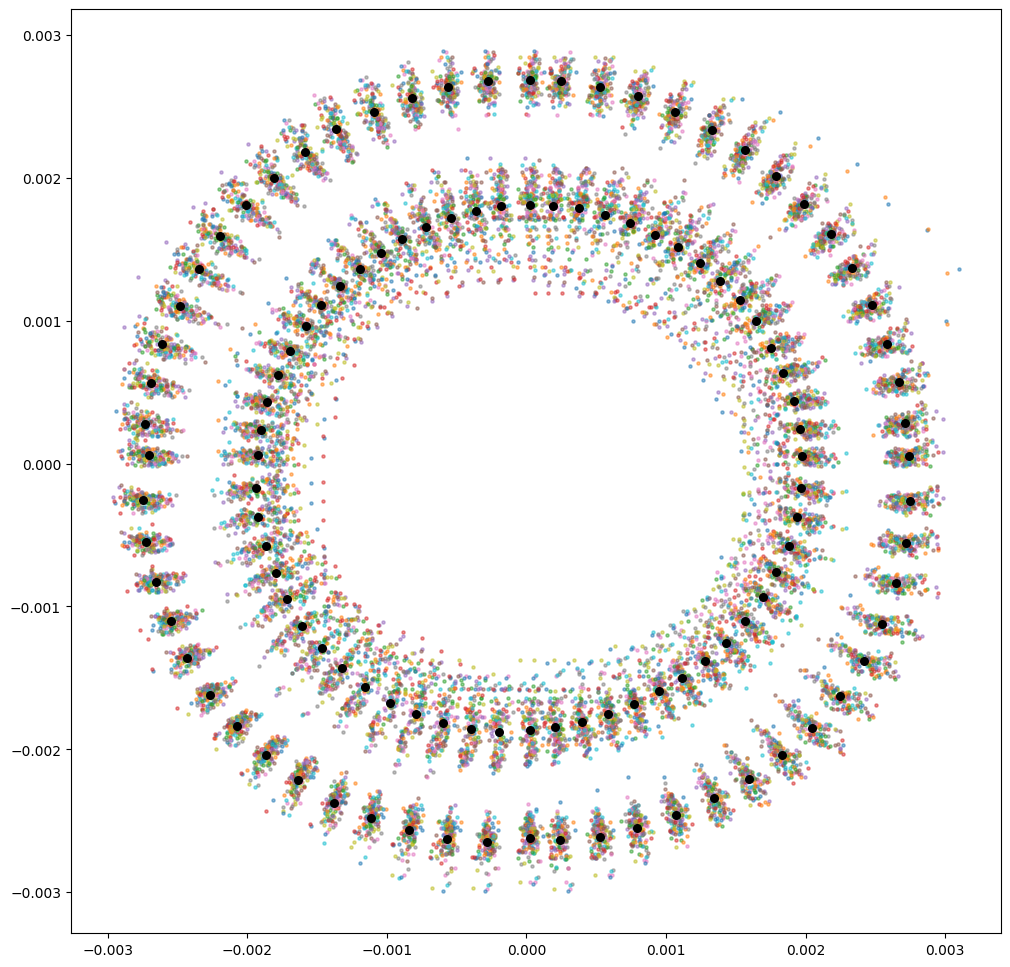

In [338]:
# mean shape - code 22
pointsets22 = data.copy()
mean22, aligned_pointsets_22 = code22(pointsets22)

plt.figure(figsize=(12, 12))
for i, pointset in enumerate(aligned_pointsets_22):
    plt.scatter(pointset[:, 0], pointset[:, 1], label=f'{i}', s = 5, alpha=0.5)

plt.scatter(mean22[:, 0], mean22[:, 1], label=f'Mean Shape', s = 30, c = 'black', alpha = 1.0)


In [365]:
shape_vectors_code11 = np.array([shape.flatten() for shape in aligned_pointsets_11])

cov_matrix_code11 = np.cov(shape_vectors_code11, rowvar=False)

# eigen decomposition
eigenvalues_code11, eigenvectors_code11 = np.linalg.eigh(cov_matrix_code11)

# sorting by descending eigenvalues
idx_code11 = np.argsort(eigenvalues_code11)[::-1]
eigenvalues_code11 = eigenvalues_code11[idx_code11]
eigenvectors_code11 = eigenvectors_code11[:, idx_code11]

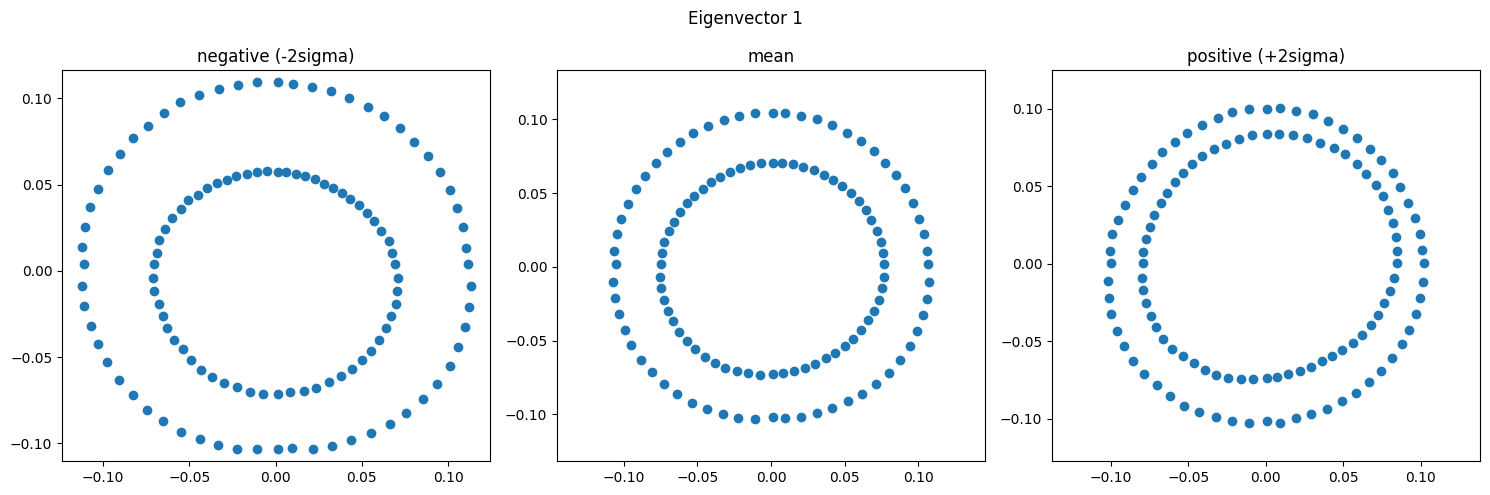

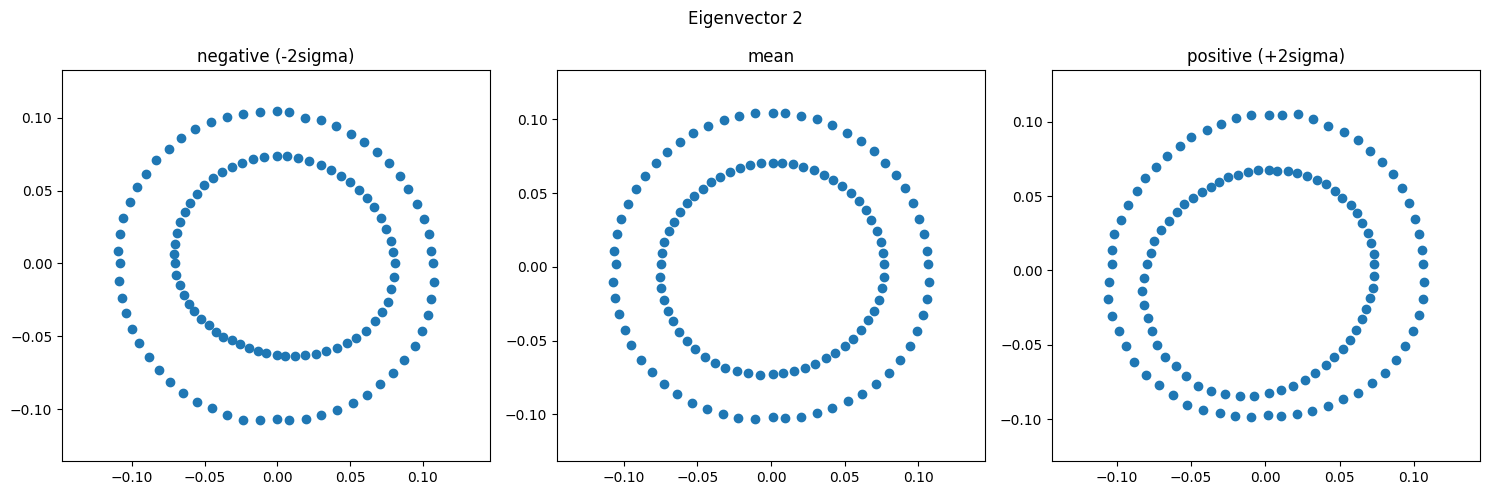

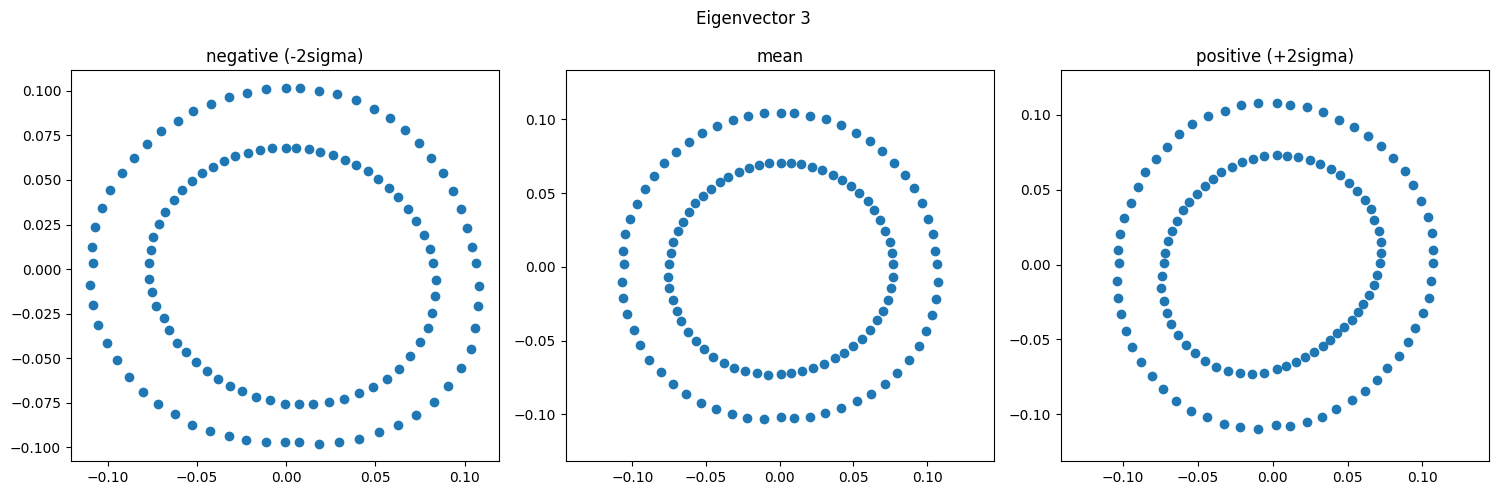

In [367]:
for i in range(3):
    plt.figure(figsize=(15, 5))
    
    # get the eigen value and corresponding eigen vector
    eigen_value = eigenvalues_code11[i]
    eigen_vector = eigenvectors_code11[:, i].reshape(-1, 2)
    
    # compute and plot negative variation
    neg_variation = mean11 - 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 1)

    plt.scatter(neg_variation[:, 0], neg_variation[:, 1])
    plt.title('negative (-2sigma)')
    plt.axis('equal')
    
    # plot the mean shape
    plt.subplot(1, 3, 2)
    plt.scatter(mean11[:, 0], mean11[:, 1])
    plt.title('mean')
    plt.axis('equal')
    
    # compute and plot positive variation
    pos_variation = mean11 + 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 3)
    plt.scatter(pos_variation[:, 0], pos_variation[:, 1])
    plt.title('positive (+2sigma)')
    plt.axis('equal')
    
    plt.suptitle(f'Eigenvector {i+1}')
    plt.tight_layout()
    plt.show()

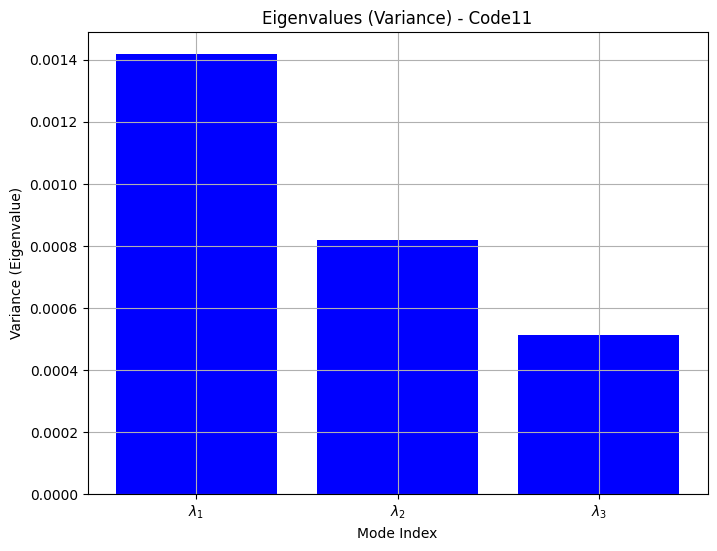

In [368]:
n = 3
# Plot eigenvalues for Code11
plt.figure(figsize=(8, 6))
plt.bar(range(1, n + 1), eigenvalues_code11[:n], color='blue')
plt.title('Eigenvalues (Variance) - Code11')
plt.xlabel('Mode Index')
plt.ylabel('Variance (Eigenvalue)')
plt.xticks(range(1, n+1), [f'$\lambda_{i}$' for i in range(1, n+1)])
plt.grid(True)
plt.show()


In [369]:
shape_vectors_code22 = np.array([shape.flatten() for shape in aligned_pointsets_22])

cov_matrix_code22 = np.cov(shape_vectors_code22, rowvar=False)

eigenvalues_code22, eigenvectors_code22 = np.linalg.eigh(cov_matrix_code22)

idx_code22 = np.argsort(eigenvalues_code22)[::-1]
eigenvalues_code22 = eigenvalues_code22[idx_code22]
eigenvectors_code22 = eigenvectors_code22[:, idx_code22]

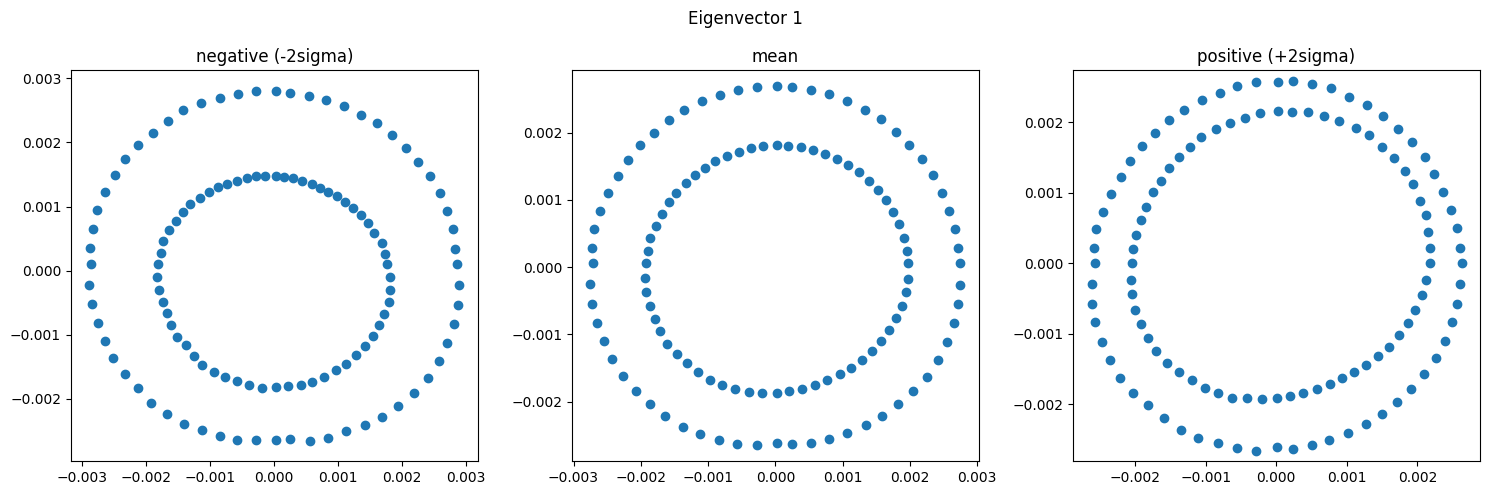

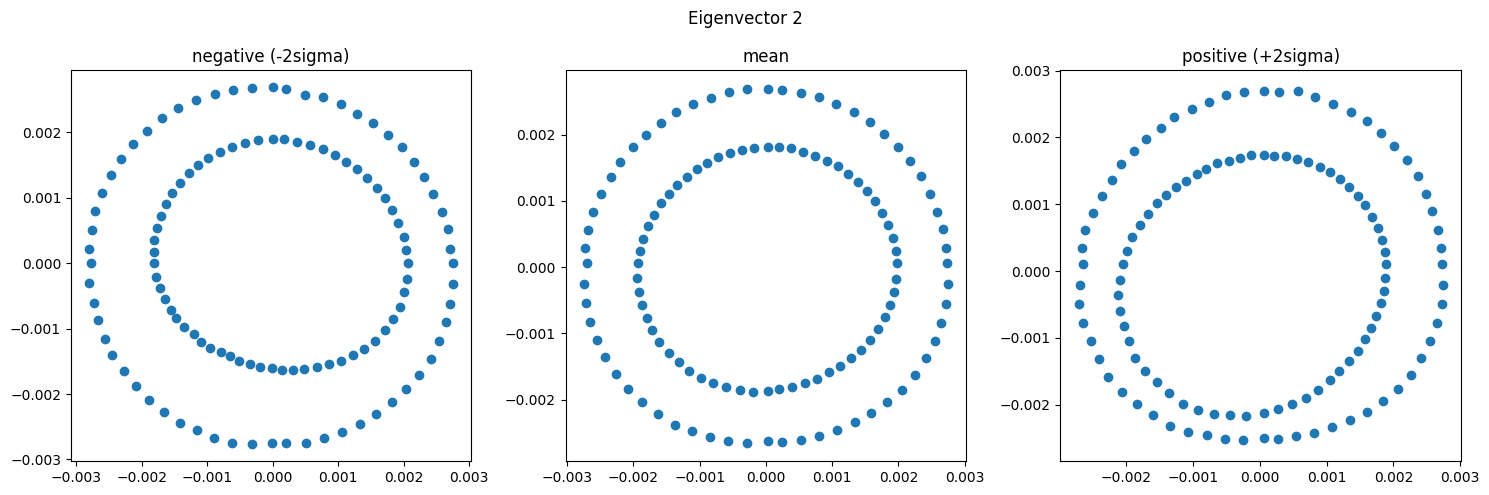

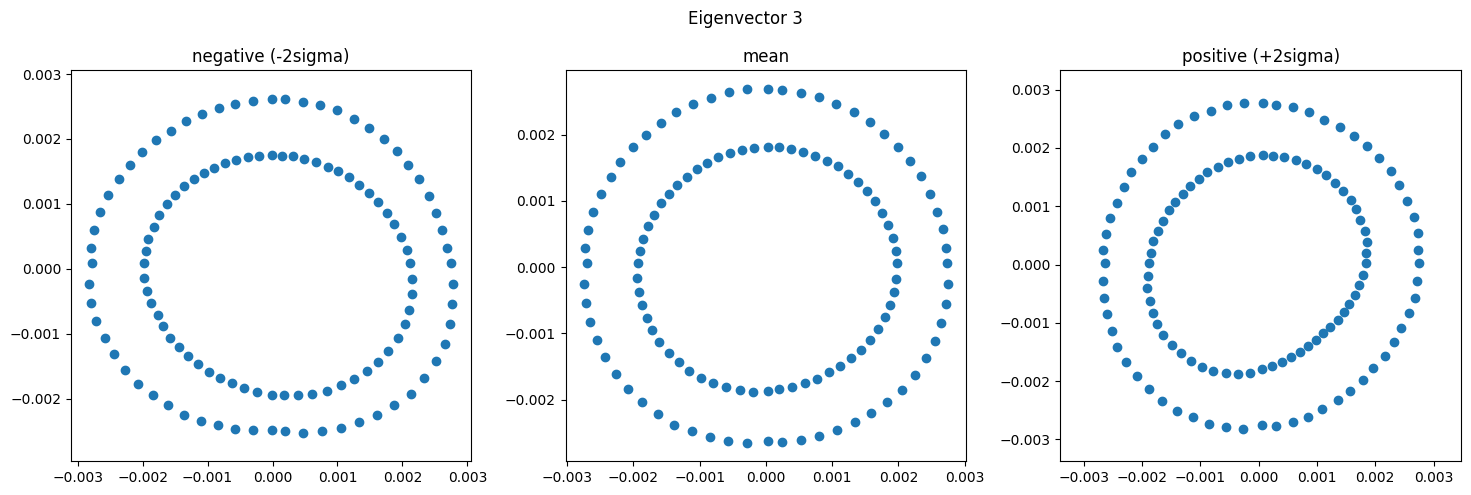

In [371]:
for i in range(3):
    plt.figure(figsize=(15, 5))
    
    # get the eigen value and corresponding eigen vector
    eigen_value = eigenvalues_code22[i]
    eigen_vector = eigenvectors_code22[:, i].reshape(-1, 2)
    
    # compute and plot negative variation
    neg_variation = mean22 - 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 1)
    plt.scatter(neg_variation[:, 0], neg_variation[:, 1])
    plt.title('negative (-2sigma)')
    plt.axis('equal')
    
    # plot the mean shape
    plt.subplot(1, 3, 2)
    plt.scatter(mean22[:, 0], mean22[:, 1])
    plt.title('mean')
    plt.axis('equal')
    
    # compute and plot positive variation
    pos_variation = mean22 + 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 3)
    plt.scatter(pos_variation[:, 0], pos_variation[:, 1])
    plt.title('positive (+2sigma)')
    plt.axis('equal')
    
    plt.suptitle(f'Eigenvector {i+1}')
    plt.tight_layout()
    plt.show()

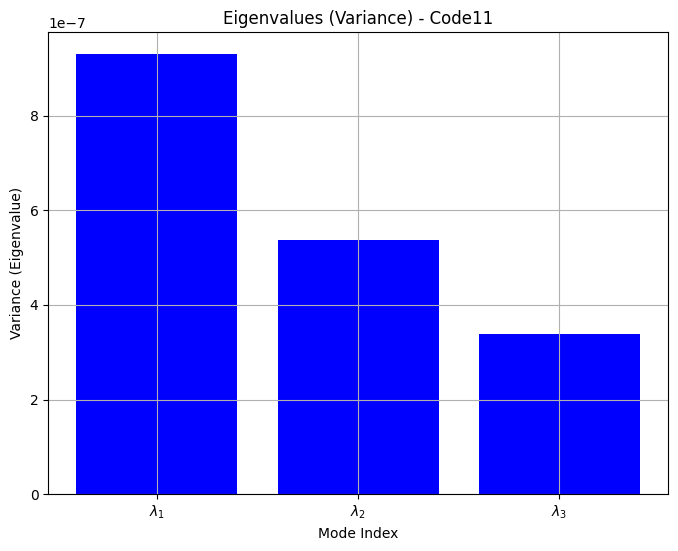

In [372]:
n = 3
# Plot eigenvalues for Code11
plt.figure(figsize=(8, 6))
plt.bar(range(1, n + 1), eigenvalues_code22[:n], color='blue')
plt.title('Eigenvalues (Variance) - Code11')
plt.xlabel('Mode Index')
plt.ylabel('Variance (Eigenvalue)')
# plt.xticks(range(1, n + 1))
plt.xticks(range(1, n+1), [f'$\lambda_{i}$' for i in range(1, n+1)])
plt.grid(True)
plt.show()
